### Stock Universe

In [ ]:
import pandas as pd
import requests
from io import StringIO
from pandas.tseries.offsets import MonthEnd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
API= 'https://en.wikipedia.org/w/api.php'
params={
    "action":"parse",
    "page":"List_of_S&P_500_companies",
    "prop":"text",
    "format":"json"
}
headers={"User-Agent": "sp500-ticker-tutorial/1.0"}

r=requests.get(API,params=params,headers=headers)
html=r.json()["parse"]["text"]['*']

sp500s=pd.read_html(StringIO(html))[0]
sp500s_removed=pd.read_html(StringIO(html))[1]
tickers=sp500s['Symbol'].astype(str).tolist()

start='2005-01-01'
sp500s

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [4]:
overall=sp500s[sp500s['Date added']>=start]
stocks=overall['Symbol']
stocks=stocks.tolist()
len(stocks)

290

In [5]:
#:Listing the removed symbols to add later for preventing the survivorship bias
removed=sp500s_removed[['Effective Date','Removed']]
removed= removed.set_index(removed['Effective Date']['Effective Date'])
removed.index=pd.to_datetime(removed.index)
removed=removed[removed.index>=start]
removed=removed.dropna()
removed=removed['Removed']
len(removed)

361

In [6]:
stocks.extend(removed['Ticker'].tolist())
len(stocks)

651

In [7]:
import yfinance as yf

df=yf.download(stocks,start=start)['Close']
df.index=pd.to_datetime(df.index)
df

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PLL"}}}
$PLL: possibly delisted; no timezone found
[                       1%                       ]  4 of 629 completed$HSP: possibly delisted; no price data found  (1d 2005-01-01 -> 2026-06-29)
[                       1%                       ]  7 of 629 completed$VAR: possibly delisted; no timezone found
[                       1%                       ]  9 of 629 completed$YHOO: possibly delisted; no timezone found
[*                      2%                       ]  10 of 629 completed$CMCSK: possibly delisted; no price data found  (1d 2005-01-01 -> 2026-06-29)
[*                      2%                       ]  11 of 629 completed$CTLT: possibly delisted; no timezone found
[**                     4%                       ]  24 of 629 completed$FRX: possibly delisted; no timezone found
[**                     5%                       ]  34 of 629 completed$PXD: pos

Ticker,AA,AAL,AAP,ABBV,ABK,ABMD,ABNB,ABS,ACAS,ACE,...,XLNX,XRAY,XRX,XTO,XYL,XYZ,YHOO,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,57.991325,NaN,24.241859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22.644217,19.625336,NaN,NaN,NaN,NaN,55.509998,44.230728,NaN
2005-01-04,56.943386,NaN,24.080431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22.461075,19.336214,NaN,NaN,NaN,NaN,54.470001,43.626915,NaN
2005-01-05,56.606529,NaN,24.124960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22.196543,18.954582,NaN,NaN,NaN,NaN,52.570000,43.469372,NaN
2005-01-06,56.849823,NaN,24.102695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22.302347,18.873636,NaN,NaN,NaN,NaN,52.650002,43.718807,NaN
2005-01-07,57.429928,NaN,23.963549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22.131424,18.769548,NaN,NaN,NaN,NaN,53.099998,42.655537,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-23,55.080002,16.139999,54.810001,234.759995,NaN,NaN,138.850006,NaN,NaN,NaN,...,NaN,10.200000,3.140000,NaN,110.400002,72.370003,NaN,237.720001,68.489998,76.839996
2026-06-24,52.299999,17.440001,57.939999,234.889999,NaN,NaN,144.399994,NaN,NaN,NaN,...,NaN,10.520000,3.140000,NaN,112.040001,75.680000,NaN,247.779999,68.300003,78.169998
2026-06-25,53.080002,17.570000,59.200001,243.139999,NaN,NaN,141.880005,NaN,NaN,NaN,...,NaN,10.780000,3.220000,NaN,117.000000,74.080002,NaN,243.389999,69.330002,77.820000


In [8]:
names=[]
for column in df.columns:

    if pd.isna(df[column]).prod()==True:
        names.append(column)
all_symb=df.columns.tolist()
for name in names:
    all_symb.remove(name)

df=df[all_symb]
df

Ticker,AA,AAL,AAP,ABBV,ABNB,ABS,ACGL,ACN,ADCT,ADT,...,WTW,WU,WYNN,XRAY,XRX,XYL,XYZ,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,57.991325,NaN,24.241859,NaN,NaN,NaN,4.025470,18.276838,NaN,NaN,...,68.672165,NaN,34.991108,22.644217,19.625336,NaN,NaN,55.509998,44.230728,NaN
2005-01-04,56.943386,NaN,24.080431,NaN,NaN,NaN,3.972643,17.847120,NaN,NaN,...,69.153542,NaN,34.916382,22.461075,19.336214,NaN,NaN,54.470001,43.626915,NaN
2005-01-05,56.606529,NaN,24.124960,NaN,NaN,NaN,3.949399,17.777803,NaN,NaN,...,68.057961,NaN,35.311386,22.196543,18.954582,NaN,NaN,52.570000,43.469372,NaN
2005-01-06,56.849823,NaN,24.102695,NaN,NaN,NaN,3.944116,17.618397,NaN,NaN,...,67.775787,NaN,36.741985,22.302347,18.873636,NaN,NaN,52.650002,43.718807,NaN
2005-01-07,57.429928,NaN,23.963549,NaN,NaN,NaN,3.985321,18.443174,NaN,NaN,...,66.912643,NaN,35.519569,22.131424,18.769548,NaN,NaN,53.099998,42.655537,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-23,55.080002,16.139999,54.810001,234.759995,138.850006,NaN,93.709999,127.010002,1.150,6.560,...,257.549988,7.030,104.150002,10.200000,3.140000,110.400002,72.370003,237.720001,68.489998,76.839996
2026-06-24,52.299999,17.440001,57.939999,234.889999,144.399994,NaN,94.919998,129.149994,1.070,6.550,...,261.500000,7.240,103.750000,10.520000,3.140000,112.040001,75.680000,247.779999,68.300003,78.169998
2026-06-25,53.080002,17.570000,59.200001,243.139999,141.880005,NaN,94.330002,125.820000,1.040,6.300,...,257.690002,7.260,99.379997,10.780000,3.220000,117.000000,74.080002,243.389999,69.330002,77.820000


In [9]:
sp500=yf.download('^GSPC',start=start)['Close']

[*********************100%***********************]  1 of 1 completed


In [10]:
#: Daily returns
ret_d=df.pct_change()
ret_d

C:\Users\Laryengea II\AppData\Local\Temp\ipykernel_16304\172204360.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_d=df.pct_change()


Ticker,AA,AAL,AAP,ABBV,ABNB,ABS,ACGL,ACN,ADCT,ADT,...,WTW,WU,WYNN,XRAY,XRX,XYL,XYZ,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-04,-0.018071,NaN,-0.006659,NaN,NaN,NaN,-0.013123,-0.023512,NaN,NaN,...,0.007010,NaN,-0.002136,-0.008088,-0.014732,NaN,NaN,-0.018735,-0.013651,NaN
2005-01-05,-0.005916,NaN,0.001849,NaN,NaN,NaN,-0.005851,-0.003884,NaN,NaN,...,-0.015843,NaN,0.011313,-0.011777,-0.019737,NaN,NaN,-0.034882,-0.003611,NaN
2005-01-06,0.004298,NaN,-0.000923,NaN,NaN,NaN,-0.001338,-0.008967,NaN,NaN,...,-0.004146,NaN,0.040514,0.004767,-0.004271,NaN,NaN,0.001522,0.005738,NaN
2005-01-07,0.010204,NaN,-0.005773,NaN,NaN,NaN,0.010447,0.046813,NaN,NaN,...,-0.012735,NaN,-0.033270,-0.007664,-0.005515,NaN,NaN,0.008547,-0.024321,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-23,-0.056041,0.003731,-0.011007,0.020651,-0.002443,0.0,0.018144,0.017464,0.055046,-0.004552,...,0.018105,-0.008463,0.005115,0.004926,0.026144,-0.012257,-0.009580,-0.032439,0.020411,0.012518
2026-06-24,-0.050472,0.080545,0.057106,0.000554,0.039971,0.0,0.012912,0.016849,-0.069565,-0.001524,...,0.015337,0.029872,-0.003841,0.031373,0.000000,0.014855,0.045737,0.042319,-0.002774,0.017309
2026-06-25,0.014914,0.007454,0.021747,0.035123,-0.017451,0.0,-0.006216,-0.025784,-0.028037,-0.038168,...,-0.014570,0.002762,-0.042121,0.024715,0.025478,0.044270,-0.021142,-0.017717,0.015081,-0.004477


In [11]:
#: Monthly returns
ret_mt=ret_d.resample('ME').agg(lambda x: (x+1).prod()-1)
ret_mt

Ticker,AA,AAL,AAP,ABBV,ABNB,ABS,ACGL,ACN,ADCT,ADT,...,WTW,WU,WYNN,XRAY,XRX,XYL,XYZ,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-31,-0.047758,0.000000,-0.010333,0.000000,0.000000,0.0,-0.035958,-0.012135,0.000000,0.000000,...,-0.065023,0.000000,0.000152,0.007728,-0.064231,0.000000,0.000000,-0.082508,0.006381,0.000000
2005-02-28,0.093996,0.000000,0.168910,0.000000,0.000000,0.0,0.129322,-0.019194,0.000000,0.000000,...,0.022492,0.000000,0.091672,-0.019618,-0.017632,0.000000,0.000000,-0.020813,-0.020323,0.000000
2005-03-31,-0.053860,0.000000,0.001389,0.000000,0.000000,0.0,-0.034716,-0.054794,0.000000,0.000000,...,-0.062192,0.000000,-0.053514,-0.009061,-0.028846,0.000000,0.000000,-0.047724,0.044175,0.000000
2005-04-30,-0.045081,0.000000,0.057483,0.000000,0.000000,0.0,-0.001249,-0.101449,0.000000,0.000000,...,-0.092758,0.000000,-0.218482,0.004044,-0.125413,0.000000,0.000000,0.005685,0.014633,0.000000
2005-05-31,-0.061356,0.000000,0.110964,0.000000,0.000000,0.0,0.116529,0.072811,0.000000,0.000000,...,0.024514,0.000000,-0.115036,0.044298,0.024151,0.000000,0.000000,-0.108878,0.016796,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-28,0.092765,-0.017293,0.107478,0.040671,0.044369,0.0,0.042795,-0.208314,0.135734,0.002500,...,-0.038744,0.027748,0.009083,0.177225,-0.178082,-0.057088,0.054112,-0.046898,-0.037011,0.050312
2026-03-31,0.070210,-0.178271,-0.007899,-0.062866,-0.065354,0.0,-0.041538,-0.049971,-0.085366,-0.173872,...,-0.044249,-0.070439,-0.061374,-0.209809,-0.269057,-0.077647,-0.055259,-0.066440,0.005936,-0.098322
2026-04-30,-0.038293,0.090317,0.133163,-0.020308,0.111498,0.0,-0.015939,-0.091101,0.008000,0.146119,...,-0.118679,0.041237,0.054751,0.012931,0.744186,-0.011213,0.171652,0.082169,0.100659,-0.023178


In [13]:
#: Market Daily returns
sp_d=sp500.pct_change()
sp_d=pd.DataFrame(sp_d)
sp_d

Ticker,^GSPC
Date,
2005-01-03,NaN
2005-01-04,-0.011671
2005-01-05,-0.003628
2005-01-06,0.003506
2005-01-07,-0.001431
...,...
2026-06-23,-0.014363
2026-06-24,-0.000983
2026-06-25,-0.000099


### Skewness vs Coskewness

In [14]:
def rolling_coskew(market_ret,stock_ret,window=252):
    results=[]
    idx=[]

    for i in range(window,len(stock_ret)):
        r_i=stock_ret.iloc[i-window:i]
        r_m=market_ret.iloc[i-window:i]

        ri=r_i-r_i.mean()
        rm=r_m-r_m.mean()

        num=(ri*(rm**2)).mean()
        denum=r_i.std(ddof=1) * r_m.std(ddof=1)**2
        results.append(num)


        idx.append(stock_ret.index[i])
        
    return pd.DataFrame({stock_ret.name: results},index=idx)

In [15]:
def rolling_coskew_all(market_ret, stock_ret, window=252):

    mu_i = stock_ret.rolling(window).mean()
    mu_m = market_ret.rolling(window).mean()

    exy2 = stock_ret.mul(market_ret**2, axis=0).rolling(window).mean()
    exy  = stock_ret.mul(market_ret, axis=0).rolling(window).mean()
    ey2 = (market_ret**2).rolling(window).mean()

    numerator = (exy2
                .sub(2 * mu_m * exy,        axis=0)
                .sub(mu_i * ey2,             axis=0)
                .add(2 * mu_i * mu_m**2,     axis=0))

    denominator = (
        stock_ret.rolling(window).std(ddof=1).mul(market_ret.rolling(window).std(ddof=1)**2, axis=0)
    )

    return  numerator/denominator

In [16]:
coskew=pd.concat([rolling_coskew_all(sp_d['^GSPC'],ret_d[col]) for col in ret_d[all_symb]],axis=1)
coskew_mt=coskew.resample('ME').last()
coskew_mt.columns=all_symb
coskew_mt

,AA,AAL,AAP,ABBV,ABNB,ABS,ACGL,ACN,ADCT,ADT,...,WTW,WU,WYNN,XRAY,XRX,XYL,XYZ,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-28,0.488734,1.242165,0.293870,-0.154025,1.073583,NaN,0.419881,0.314185,0.198271,0.486721,...,0.161422,0.950055,0.995022,0.434175,0.540045,0.476044,0.548267,0.570211,0.117778,0.490616
2026-03-31,0.549873,1.364484,0.316235,-0.170926,1.162158,NaN,0.432164,0.339944,0.202913,0.522056,...,0.160836,0.979695,1.049494,0.469751,0.559315,0.525310,0.627524,0.627186,0.182127,0.473600
2026-04-30,0.078593,0.180614,0.042373,0.278915,0.090014,NaN,0.213086,-0.068733,-0.061457,-0.007240,...,0.019381,-0.037924,0.155430,0.135237,-0.061956,0.076965,-0.071609,0.221142,0.064371,0.015210


In [17]:
raw_skew=ret_d.rolling(window=252).skew()
raw_skew_mt=raw_skew.resample('ME').last()
raw_skew_mt

Ticker,AA,AAL,AAP,ABBV,ABNB,ABS,ACGL,ACN,ADCT,ADT,...,WTW,WU,WYNN,XRAY,XRX,XYL,XYZ,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-28,0.271175,0.892058,6.073573,-0.593943,0.490152,0.0,-0.741824,-0.390292,1.551285,-0.259453,...,-1.843008,0.914978,0.583789,0.930826,-0.150029,0.501869,-0.298187,-0.559624,-1.518043,-1.675084
2026-03-31,0.265718,0.948514,6.068201,-0.607641,0.560051,0.0,-0.771053,-0.278724,1.594319,-1.543613,...,-1.790361,1.022293,0.558261,0.894177,-0.171864,0.542945,-0.301183,-0.573873,-1.547530,-1.549516
2026-04-30,0.389076,0.477258,6.330478,-0.191656,-0.489571,0.0,-0.439275,-0.213877,1.735423,-1.718982,...,-2.608534,0.837777,0.228006,1.076728,1.923844,0.632888,-0.595561,-0.299037,-1.342746,-1.836521


In [18]:
def prep_signal(df,lower=0.01,upper=0.99):
    clipped=df.apply(lambda x: x.clip(x.quantile(lower),x.quantile(upper)),axis=1)

    return clipped.sub(clipped.mean(axis=1), axis=0).div(clipped.std(axis=1), axis=0)

raw_skew_clean=prep_signal(raw_skew_mt)
coskew_clean=prep_signal(coskew_mt)
ret_mt_clean= ret_mt.clip(-0.40, 0.40)

In [19]:
corr_ts=coskew_clean.corrwith(raw_skew_clean,axis=1)
corr_ts.name='Corr'
corr=coskew_clean.corrwith(raw_skew_clean,axis=1).describe()
corr


count    246.000000
mean       0.172049
std        0.125150
min       -0.117733
25%        0.076983
50%        0.164076
75%        0.235176
max        0.538115
dtype: float64

<Axes: title={'center': 'Monthly cross-sectional correlation: raw skew vs coskew'}, xlabel='Date'>

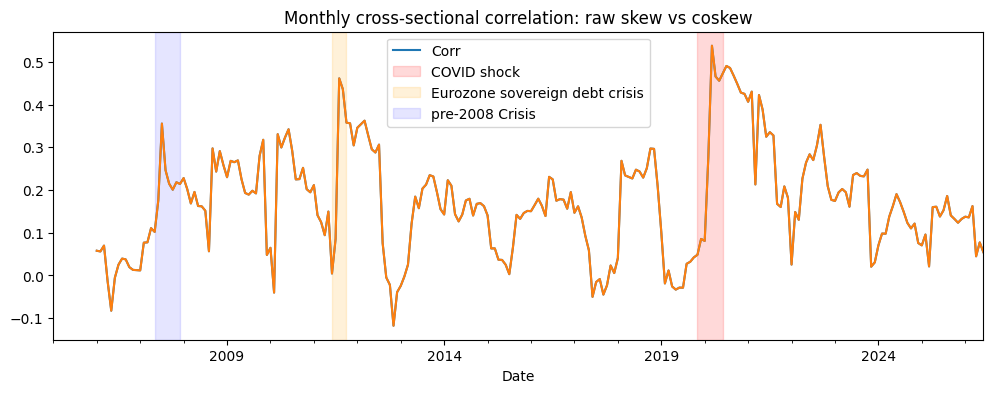

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
corr_ts.plot(ax=ax)
ax.axvspan('2019-11-01', '2020-06-01', alpha=0.15, color='red', label='COVID shock')
ax.axvspan('2011-06-01', '2011-10-01', alpha=0.15, color='orange', label='Eurozone sovereign debt crisis')
ax.axvspan('2007-05-01', '2007-12-01', alpha=0.1, color='blue', label='pre-2008 Crisis')
ax.set_title('Cross-sectional correlation: raw skewness vs coskewness')
ax.legend()
plt.savefig('results/rawskew_vs_coskew.png', dpi=150)
corr_ts.plot(title='Monthly cross-sectional correlation: raw skew vs coskew')

### Portfolio

Now, we are ready to form our long-short positions to test our signal.

In [24]:
def portfolio(signal,monthly_ret,n_quint=5):
    ls_ret=[]
    idx=[]

    dates=signal.index

    for i in range(len(dates)-1):
        signal_t=signal.iloc[i].dropna()
        return_t1=monthly_ret.iloc[i+1]

        if len(signal_t) < 10 * n_quint:
            ls_ret.append(np.nan)
            idx.append(dates[i+1])
            continue

        quintiles=pd.qcut(signal_t,n_quint,labels=False)

        long_stocks=quintiles[quintiles==0].index
        short_stocks=quintiles[quintiles==n_quint-1].index

        long_ret=return_t1[long_stocks].clip(-0.40, 0.40).mean()
        short_ret=return_t1[short_stocks].clip(-0.40, 0.40).mean()

        ls_ret.append(long_ret-short_ret)
        idx.append(dates[i+1])

    return pd.Series(ls_ret,idx,name='long-short')


In [26]:
ls_raw=portfolio(raw_skew_clean,ret_mt_clean)
ls_coskew=portfolio(coskew_clean,ret_mt_clean)

In [27]:
def perf_metrics(returns):
    r=returns.dropna()
    ann_ret=r.mean()*12
    ann_vol=r.std()*np.sqrt(12)
    sharpe=ann_ret/ann_vol

    cum = (1+r).cumprod()
    dd = cum / cum.cummax() -1

    return {
        'annualized returns': round(ann_ret,4),
        'annualized vol': round(ann_vol,4),
        'sharpe ratio': round(sharpe,4),
        'max drawrown': round(dd.min(),4),
        'n_months':len(r)
    }

In [28]:
perf_metrics(ls_raw)

{'annualized returns': np.float64(-0.0069),
 'annualized vol': np.float64(0.0758),
 'sharpe ratio': np.float64(-0.0914),
 'max drawrown': np.float64(-0.3546),
 'n_months': 245}

In [29]:
perf_metrics(ls_coskew)

{'annualized returns': np.float64(0.0298),
 'annualized vol': np.float64(0.1097),
 'sharpe ratio': np.float64(0.2719),
 'max drawrown': np.float64(-0.3418),
 'n_months': 245}

In [30]:
def computeIC(signal,monthly_ret):
    ic=[]
    idx=[]

    dates=signal.index

    for i in range(len(dates)-1):
        signal_t = signal.iloc[i].dropna()
        return_t1 = monthly_ret.iloc[i+1].dropna()

        common=signal_t.index.intersection(return_t1.index)

        if len(common)<20:
            continue

        ic.append(signal_t[common].corr(return_t1[common]))
        idx.append(dates[i+1])

    return pd.Series(ic,idx,name='IC')

In [31]:
ic_raw_skew = computeIC(raw_skew_clean, ret_mt_clean)
ic_coskew   = computeIC(coskew_clean, ret_mt_clean)

for name, ic in [('raw skewness', ic_raw_skew), ('coskewness', ic_coskew)]:
    print(f"\n{name}")
    print(f"  IC mean:   {ic.mean():.4f}")
    print(f"  IC std:    {ic.std():.4f}")
    print(f"  IC t-stat: {ic.mean() / ic.std() * np.sqrt(len(ic)):.4f}")
    print(f"  Hit rate:  {(ic > 0).mean():.4f}")


raw skewness
  IC mean:   -0.0062
  IC std:    0.0941
  IC t-stat: -1.0237
  Hit rate:  0.4816

coskewness
  IC mean:   -0.0099
  IC std:    0.1087
  IC t-stat: -1.4279
  Hit rate:  0.4776


In [32]:
from scipy import stats

def fama_macbeth(signal: pd.DataFrame,
                 monthly_returns: pd.DataFrame) -> dict:
    gammas = []
    dates  = signal.index

    for i in range(len(dates) - 1):
        sig_t  = signal.iloc[i].dropna()
        ret_t1 = monthly_returns.iloc[i + 1].dropna()

        common = sig_t.index.intersection(ret_t1.index)
        if len(common) < 20:
            continue

        x = sig_t[common].values
        y = ret_t1[common].values
        slope, _, _, _, _ = stats.linregress(x, y)
        gammas.append(slope)

    gammas = np.array(gammas)
    t_stat = gammas.mean() / (gammas.std() / np.sqrt(len(gammas)))

    return {
        'gamma mean' : round(gammas.mean(), 6),
        'gamma std'  : round(gammas.std(), 6),
        't-stat'     : round(t_stat, 4),
        'n_months'   : len(gammas)
    }

print(fama_macbeth(raw_skew_clean, ret_mt_clean))
print(fama_macbeth(coskew_clean,   ret_mt_clean))

{'gamma mean': np.float64(-0.000458), 'gamma std': np.float64(0.008458), 't-stat': np.float64(-0.8468), 'n_months': 245}
{'gamma mean': np.float64(-0.000752), 'gamma std': np.float64(0.010877), 't-stat': np.float64(-1.0814), 'n_months': 245}


### Investigating the Skewness: GARCH & Simulation

In [59]:
monthly_mean_skew = raw_skew_mt.mean(axis=1).dropna()
monthly_mean_coskew = coskew_mt.mean(axis=1).dropna()

for name, series in [('raw skewness', monthly_mean_skew), 
                     ('coskewness',   monthly_mean_coskew)]:
    t_stat, p_val = stats.ttest_1samp(series, 0)
    print(f"\n{name}")
    print(f"  mean amplitude : {series.mean():.6f}")
    print(f"  std            : {series.std():.6f}")
    print(f"  t-stat         : {t_stat:.4f}")
    print(f"  p-value        : {p_val:.6f}")


raw skewness
  mean amplitude : 0.179524
  std            : 0.169384
  t-stat         : 16.6233
  p-value        : 0.000000

coskewness
  mean amplitude : -0.114571
  std            : 0.225748
  t-stat         : -7.9601
  p-value        : 0.000000


Both skewness seem to be statistically significant. Now, we want to extract the GARCH-component and analyze the residuals

In [ ]:
from arch import arch_model
import warnings

def fit_garch(returns, p=1, q=1):

    r=returns.dropna()*100
    model=arch_model(r,vol='GARCH',p=p,q=q, dist='normal',rescale=True)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        result=model.fit(disp='off', show_warning=False, options={'ftol': 1e-9, 'maxiter': 500})

    return {
        'params'    : result.params,
        'omega'     : result.params['omega'],
        'alpha'     : result.params['alpha[1]'],
        'beta'      : result.params['beta[1]'],
        'persistance': result.params['alpha[1]']+result.params['beta[1]'],
        'cond_vol'  : result.conditional_volatility / 100,  # back to decimal
        'resid'     : result.resid / 100,
        'std_resid' : result.std_resid,
        'loglik'    : result.loglikelihood,
        'aic'       : result.aic }

In [ ]:
garch_fit={}
failed=[]

for ticker in ret_d.columns:
    stock=ret_d[ticker].dropna()

    if len(stock) < 504:
        failed.append(ticker)
        continue

    try:
        garch_fit[ticker]=fit_garch(stock)
    except Exception as e:
        failed.append(ticker)

pd.to_pickle(garch_fit, "results/garch_fits.pkl")

print(f'Succesful fits: {len(garch_fit)}')
print(f'Failes fits: {len(failed)}')

Succesful fits: 445
Failes fits: 16


In [51]:
valid_tickers=[ ticker for ticker, fit in garch_fit.items() if fit['persistance']<0.99 and fit['omega']<5]

print(len(valid_tickers))

299


In [50]:
params=pd.DataFrame(
    {ticker:{'omega' : fit['omega'],
        'alpha' : fit['alpha'],
        'beta'  : fit['beta'],
        'persistence' : fit['alpha'] + fit['beta']} for ticker,fit in garch_fit.items()}).T

print(params.describe())

              omega       alpha        beta  persistence
count  4.450000e+02  445.000000  445.000000   445.000000
mean   1.013065e+01    0.095069    0.850956     0.946025
std    1.936247e+02    0.080735    0.139301     0.097494
min    4.923001e-09    0.000000    0.008326     0.186447
25%    4.920201e-02    0.051035    0.822409     0.944334
50%    1.057291e-01    0.080204    0.891435     0.978470
75%    3.397764e-01    0.109909    0.933930     0.993084
max    4.081709e+03    0.686686    0.999042     1.014073


In [52]:
valid_params=params.loc[valid_tickers]

print(valid_params.describe())

            omega       alpha        beta  persistence
count  299.000000  299.000000  299.000000   299.000000
mean     0.437872    0.101682    0.835049     0.936731
std      0.673372    0.066067    0.119482     0.074903
min      0.000814    0.011181    0.008326     0.341814
25%      0.083607    0.065972    0.803165     0.918317
50%      0.169846    0.089835    0.873733     0.965431
75%      0.445377    0.115529    0.907702     0.980740
max      4.449271    0.686686    0.971638     0.989959


In [55]:
unstable = params[params['persistence'] > 0.999]
print(f"\nNear unit-root processes: {len(unstable)}")


Near unit-root processes: 47


#### Simulation and Skew

In [56]:
def simulate_skewness(fit,n_simulations=1000,day=252,window=252):
    omega=fit['omega']/10000
    alpha=fit['alpha']
    beta=fit['beta']

    sigma2_0=omega/(1-alpha-beta)

    sim_skew=[]

    for i in range(n_simulations):
        returns=[]
        sigma2=sigma2_0

        for t in range(day):
            z=np.random.standard_normal()
            r=np.sqrt(sigma2)*z
            returns.append(r)

            sigma2= omega+ alpha * r**2 + beta * sigma2

        returns=np.array(returns)

        mean=returns.mean()
        std=returns.std()

        if std>0:
            skew=((returns-mean)**3).mean()/std**3
            sim_skew.append(skew)

    sim_skew=np.array(sim_skew)

    return {
        'skew_garch_mean' : sim_skew.mean(),
        'skew_garch_std'  : sim_skew.std(),
        'skew_garch_p05'  : np.percentile(sim_skew, 5),
        'skew_garch_p95'  : np.percentile(sim_skew, 95),
    }

In [57]:
np.random.seed(42)

garch_sim={}

for stock in valid_tickers:
    garch_sim[stock]=simulate_skewness(garch_fit[stock])

garch_simdf=pd.DataFrame(garch_sim).T

print(garch_simdf.describe())

       skew_garch_mean  skew_garch_std  skew_garch_p05  skew_garch_p95
count       299.000000      299.000000      299.000000      299.000000
mean          0.000065        0.199750       -0.318336        0.319450
std           0.007327        0.071165        0.102187        0.111709
min          -0.015518        0.144829       -1.373096        0.229614
25%          -0.004611        0.170625       -0.330962        0.277529
50%           0.000152        0.185513       -0.296761        0.298287
75%           0.004297        0.204708       -0.275620        0.326747
max           0.067242        0.937776       -0.237391        1.482136


Results are striking: the raw skewness is not realized only by the GARCH. If confirmed statistically, what accounts for the skewness must be everything else contributing at the 'interaction' level.

In [105]:
realized_rawskew=raw_skew_mt[valid_tickers].mean(axis=0)
garch_rawskew= pd.Series({ticker: garch_sim[ticker]['skew_garch_mean'] for ticker in valid_tickers})
resid_rawskew=realized_rawskew-garch_rawskew

In [106]:
t_stat, p_val = stats.ttest_1samp(resid_rawskew.dropna(), 0)
print(f"Residual skewness amplitude")
print(f"  mean : {resid_rawskew.mean():.6f}")
print(f"  std  : {resid_rawskew.std():.6f}")
print(f"  t-stat : {t_stat:.4f}")
print(f"  p-value: {p_val:.6f}")

Residual skewness amplitude
  mean : 0.068301
  std  : 0.340790
  t-stat : 3.4656
  p-value: 0.000607


In [114]:
std_resid_df=pd.DataFrame({
    ticker: pd.Series(
        garch_fit[ticker]['std_resid'],
        index=ret_d[ticker].dropna().index
    ) for ticker in valid_tickers
})

skew_residuals_daily=std_resid_df.rolling(252).skew()
skew_residuals_monthly=skew_residuals_daily.resample('ME').last()

residual_mean_ts=skew_residuals_monthly.median(axis=1).dropna()

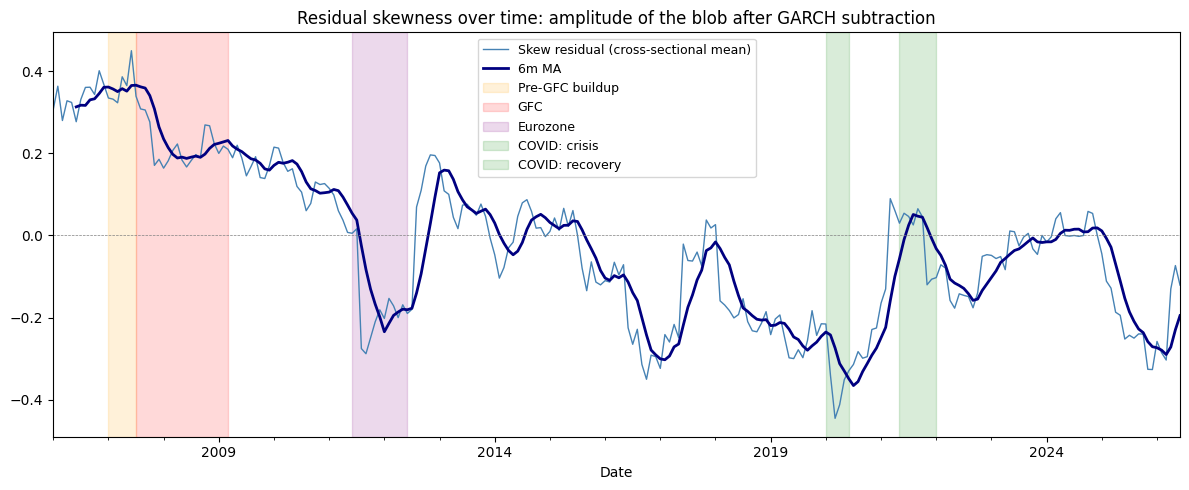

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

residual_mean_ts.plot(ax=ax, color='steelblue', linewidth=1, label='Skew residual (cross-sectional mean)')
residual_mean_ts.rolling(6).mean().plot(ax=ax, color='navy', linewidth=2, label='6m MA')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

ax.axvspan('2007-01-01', '2007-07-01', alpha=0.15, color='orange', label='Pre-GFC buildup')
ax.axvspan('2007-07-01', '2009-03-01', alpha=0.15, color='red',    label='GFC')
ax.axvspan('2011-06-01', '2012-06-01', alpha=0.15, color='purple', label='Eurozone')
ax.axvspan('2020-01-01', '2020-06-01', alpha=0.15, color='green',  label='COVID: crisis')
ax.axvspan('2021-05-01', '2022-01-01', alpha=0.15, color='green',  label='COVID: recovery')

ax.set_title('Residual skewness over time: amplitude of the blob after GARCH subtraction')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('results/residual_skewness_regime.png', dpi=150)
plt.show()

In [124]:
regimes = {
    'pre_GFC'   : ('2006-01-01', '2007-07-01'),
    'GFC'       : ('2007-07-01', '2009-03-01'),
    'calm_2010' : ('2009-03-01', '2011-06-01'),
    'eurozone'  : ('2011-06-01', '2012-06-01'),
    'calm_2013' : ('2012-06-01', '2020-01-01'),
    'covid'     : ('2020-01-01', '2020-06-01'),
    'post_covid': ('2020-06-01', '2026-01-01'),
}

print(f"{'Regime':<15} {'Mean':>8} {'Std':>8} {'t-stat':>8}")
print("-" * 42)
for name, (start, end) in regimes.items():
    subset = residual_mean_ts[start:end].dropna()
    if len(subset) < 3:
        continue
    t, _ = stats.ttest_1samp(subset, 0)
    print(f"{name:<15} {subset.mean():>8.4f} {subset.std():>8.4f} {t:>8.4f}")

Regime              Mean      Std   t-stat
------------------------------------------
pre_GFC           0.3464   0.0417  35.2211
GFC               0.2230   0.0527  18.9216
calm_2010         0.1389   0.0564  12.7996
eurozone         -0.1731   0.0957  -6.2707
calm_2013        -0.0885   0.1414  -5.9675
covid            -0.3529   0.0881  -8.9596
post_covid       -0.0924   0.1188  -6.3654


In [123]:
print(skew_residuals_monthly['2020-01-01':'2021-01-01'].abs().max().sort_values(ascending=False).head(10))

SCG     216905.359604
BMS        116.073739
EXPE         9.065198
IT           6.874413
ADT          6.437599
DPZ          6.083926
KHC          6.042923
ABBV         5.745244
SLM          5.248011
ALGN         4.743168
dtype: float64
